# 2. Exploratory Data Analysis (EDA)

## 2.1. Introduction

Exploratory Data Analysis (EDA) is the process of visualizing and summarizing the main characteristics of a dataset. In this notebook, we will explore the historical price data of Bitcoin and the S&P 500. Our goal is to uncover patterns, identify anomalies, and check assumptions before any formal modeling. We will analyze daily returns, visualize price trends, and examine the correlation between the two assets. This analysis is fundamental to understanding the behavior and relationship of our investment choices.

## 2.2. Import Libraries and Load Data

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Ignore FutureWarning from seaborn
warnings.simplefilter('ignore', category=FutureWarning)

# Set plot style
sns.set(style='whitegrid', palette='viridis')

In [98]:
PROCESSED_DATA_FILE = '../data/processed/btc_sp500_data.csv'
data = pd.read_csv(PROCESSED_DATA_FILE, index_col='Date', parse_dates=True)

print("Data Head:")
print(data.head())

Data Head:
               BTC-USD        ^GSPC
Date                               
2015-01-01  314.248993  2058.199951
2015-01-02  315.032013  2058.199951
2015-01-03  281.082001  2058.199951
2015-01-04  264.195007  2058.199951
2015-01-05  274.473999  2020.579956


## 2.3. Calculate Daily Returns

Returns are a more standardized measure than prices for analyzing investment performance. We calculate the daily percentage change in price to represent the daily returns for each asset.

In [99]:
returns = data.pct_change()
# Replace infinite values with NaN as they can occur with zero prices and cause warnings in plots
returns.replace([np.inf, -np.inf], np.nan, inplace=True)
# Drop rows with NaN values (the first row and any rows that had infinity)
returns.dropna(inplace=True)

print("Returns Head:")
print(returns.head())

Returns Head:
             BTC-USD     ^GSPC
Date                          
2015-01-02  0.002492  0.000000
2015-01-03 -0.107767  0.000000
2015-01-04 -0.060079  0.000000
2015-01-05  0.038907 -0.018278
2015-01-06  0.042682 -0.008893


## 2.4. Summary Statistics

We'll compute descriptive statistics for the daily returns. This includes the mean, standard deviation (a measure of volatility), and various quantiles. These stats provide a quick overview of the risk and return profile of each asset.

In [100]:
print("Summary Statistics of Daily Returns:")
print(returns.describe())

Summary Statistics of Daily Returns:
           BTC-USD        ^GSPC
count  4017.000000  4017.000000
mean      0.002027     0.000343
std       0.035218     0.009363
min      -0.371695    -0.119841
25%      -0.012136    -0.001446
50%       0.001245     0.000000
75%       0.016057     0.002996
max       0.252472     0.095154


## 2.5. Visualize Price Evolution

A line plot of the adjusted closing prices over time shows the long-term trend of each asset. To make the comparison clearer, we'll normalize the prices to start at a common value (100). This helps in comparing the relative performance of the assets over the period.

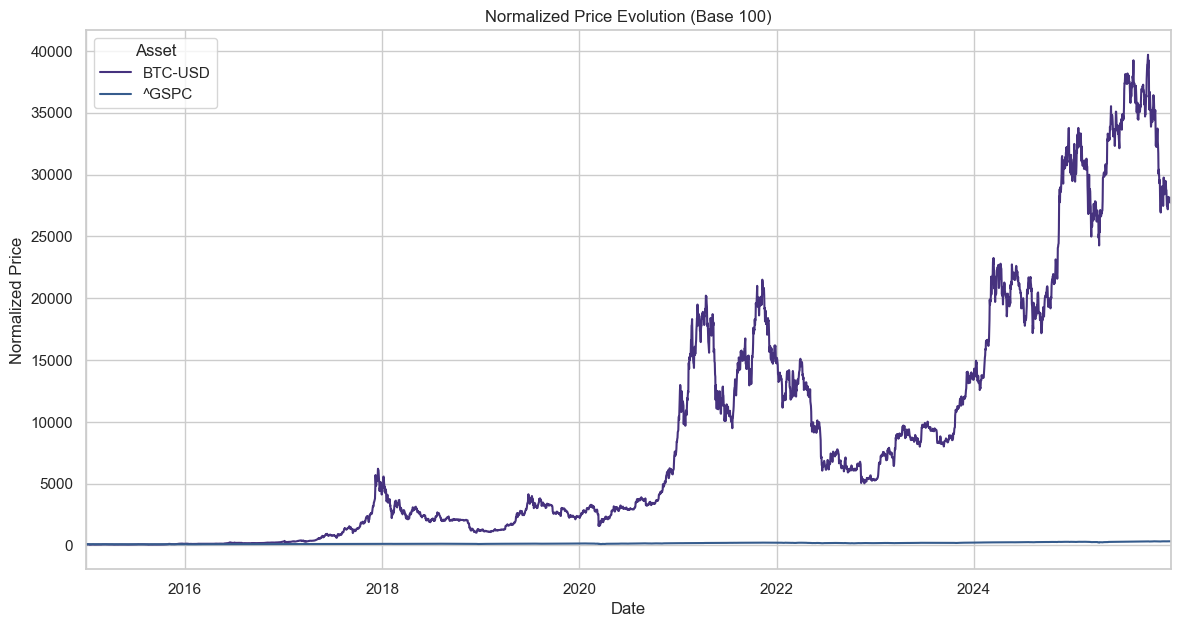

In [101]:
plt.figure(figsize=(14, 7))
(data / data.iloc[0] * 100).plot(ax=plt.gca())
plt.title('Normalized Price Evolution (Base 100)')
plt.ylabel('Normalized Price')
plt.xlabel('Date')
plt.legend(title='Asset')
plt.show()

### Interpretation
The normalized price chart starkly illustrates the high-growth, high-volatility nature of Bitcoin compared to the steadier, more conservative growth of the S&P 500. Bitcoin's price shows several orders of magnitude of growth, while the S&P 500 follows a more linear upward trend.

## 2.6. Visualize Distribution of Daily Returns

A histogram of daily returns helps us understand the distribution of price changes. We can observe the frequency and magnitude of daily gains and losses. This is a key step in assessing volatility and risk.

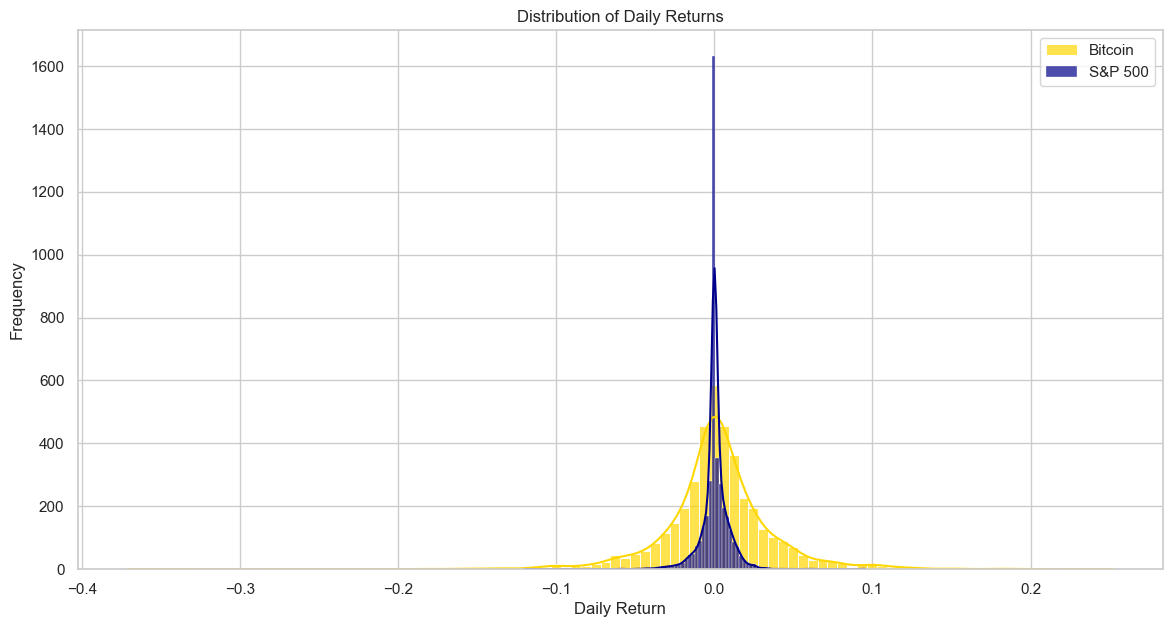

In [102]:
plt.figure(figsize=(14, 7))
sns.histplot(returns['BTC-USD'], bins=100, kde=True, color='gold', label='Bitcoin', alpha=0.7)
sns.histplot(returns['^GSPC'], bins=100, kde=True, color='darkblue', label='S&P 500', alpha=0.7)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Interpretation
The distribution plot shows that Bitcoin's returns are far more spread out (higher standard deviation) than the S&P 500's, confirming its higher volatility. Both distributions are centered around zero but have 'fat tails', indicating that extreme price swings occur more frequently than a normal distribution would predict.

## 2.7. Visualize Price History

To provide context for the returns analysis, let's visualize the raw price history of both assets. Because their price scales are so different, we'll use a dual-axis plot to effectively compare their movements over time.

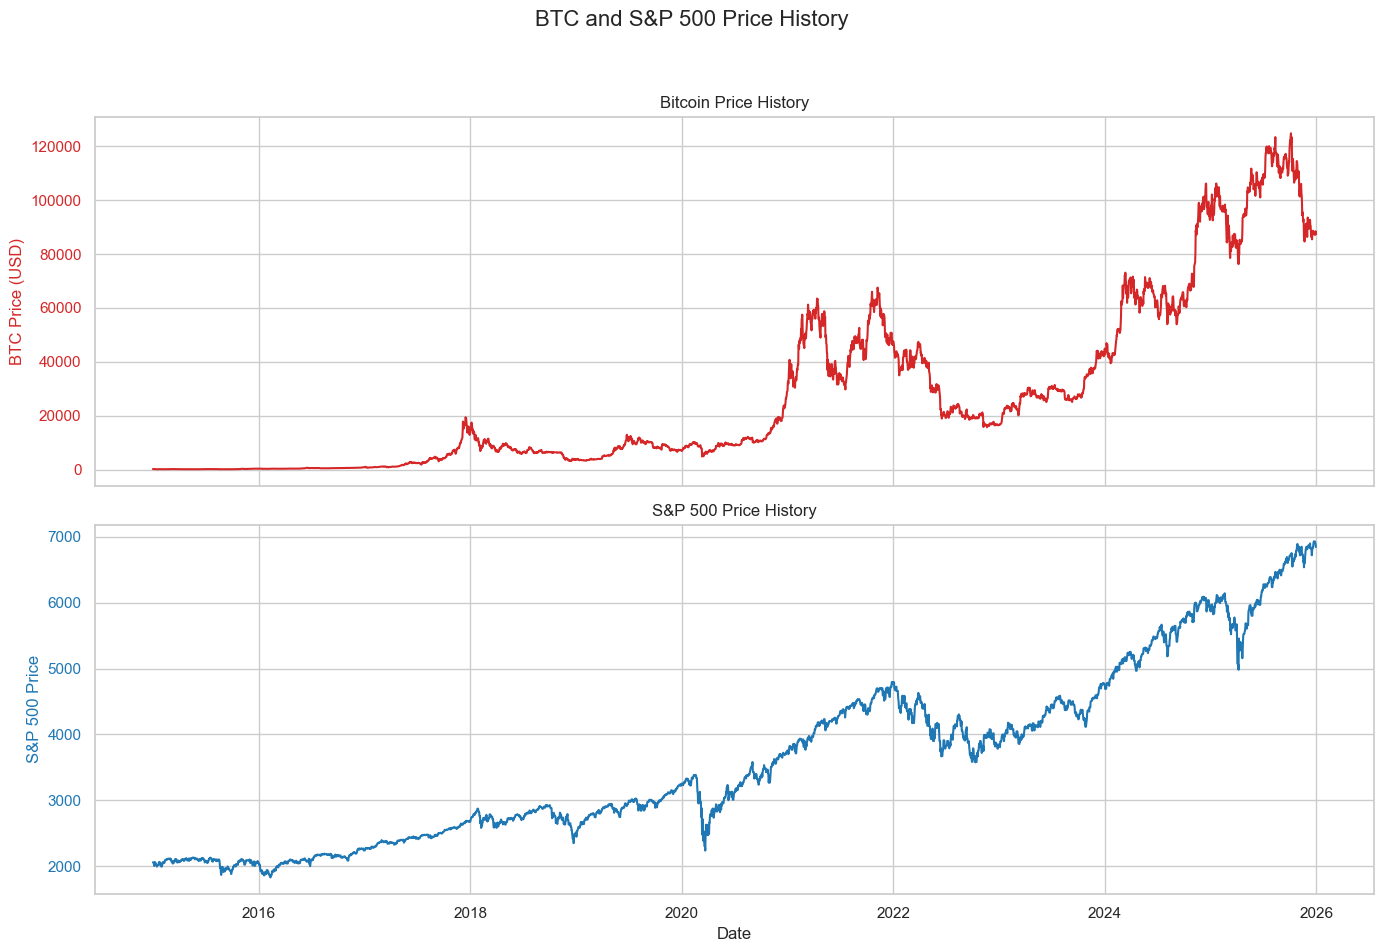

In [103]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot Bitcoin
color = 'tab:red'
ax1.set_ylabel('BTC Price (USD)', color=color)
ax1.plot(data.index, data['BTC-USD'], color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Bitcoin Price History')
ax1.grid(True)

# Plot S&P 500
color = 'tab:blue'
ax2.set_ylabel('S&P 500 Price', color=color)
ax2.plot(data.index, data['^GSPC'], color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_title('S&P 500 Price History')
ax2.grid(True)

ax2.set_xlabel('Date')
fig.suptitle('BTC and S&P 500 Price History', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Interpretation

The price history chart reveals that both Bitcoin and the S&P 500 have experienced significant long-term growth. Both assets appear to follow similar broad market trends, showing periods of growth and consolidation at roughly the same times. However, the chart also underscores their different volatility profiles; Bitcoin's price exhibits much larger and more frequent swings, while the S&P 500's growth is characterized by a steadier upward trend.

## 2.8. Correlation Analysis

We'll examine the correlation between the daily returns of Bitcoin and the S&P 500. A correlation matrix and a heatmap provide a quick visual summary of how the two assets move in relation to each other. A low correlation can be beneficial for diversification.

Correlation Matrix:
          BTC-USD     ^GSPC
BTC-USD  1.000000  0.211505
^GSPC    0.211505  1.000000


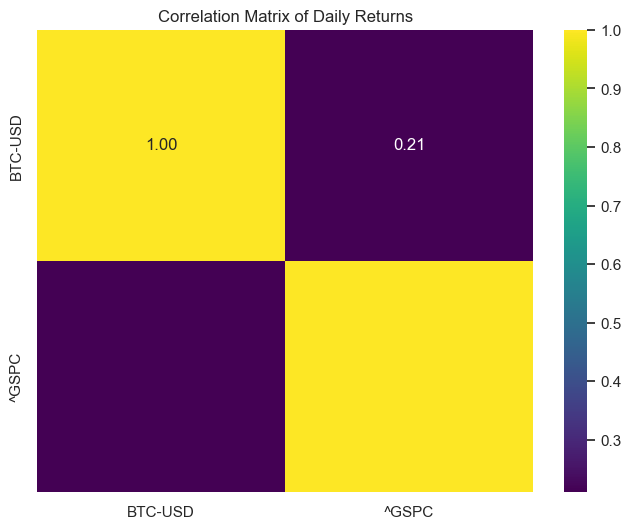

In [104]:
correlation_matrix = returns.corr()
print("Correlation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Matrix of Daily Returns')
plt.show()

### Interpretation
The heatmap reveals a correlation score of 0.21 between the daily returns of Bitcoin and the S&P 500 over the full period. This indicates a weak positive correlation, suggesting that while the assets occasionally move in the same direction, they are not strongly linked. This relationship highlights potential diversification benefits.

## 3. Analysis of Recent Data (2020-Present)

To see if the relationship between Bitcoin and the S&P 500 has changed in recent years, we will now repeat the analysis, focusing on the period from January 1, 2020, to the present.

In [105]:
# Create a new dataframe for the period from 2020 onwards
data_recent = data.loc['2020-01-01':]
returns_recent = data_recent.pct_change().dropna()

### 3.1. Visualize Price History (2020-Present)

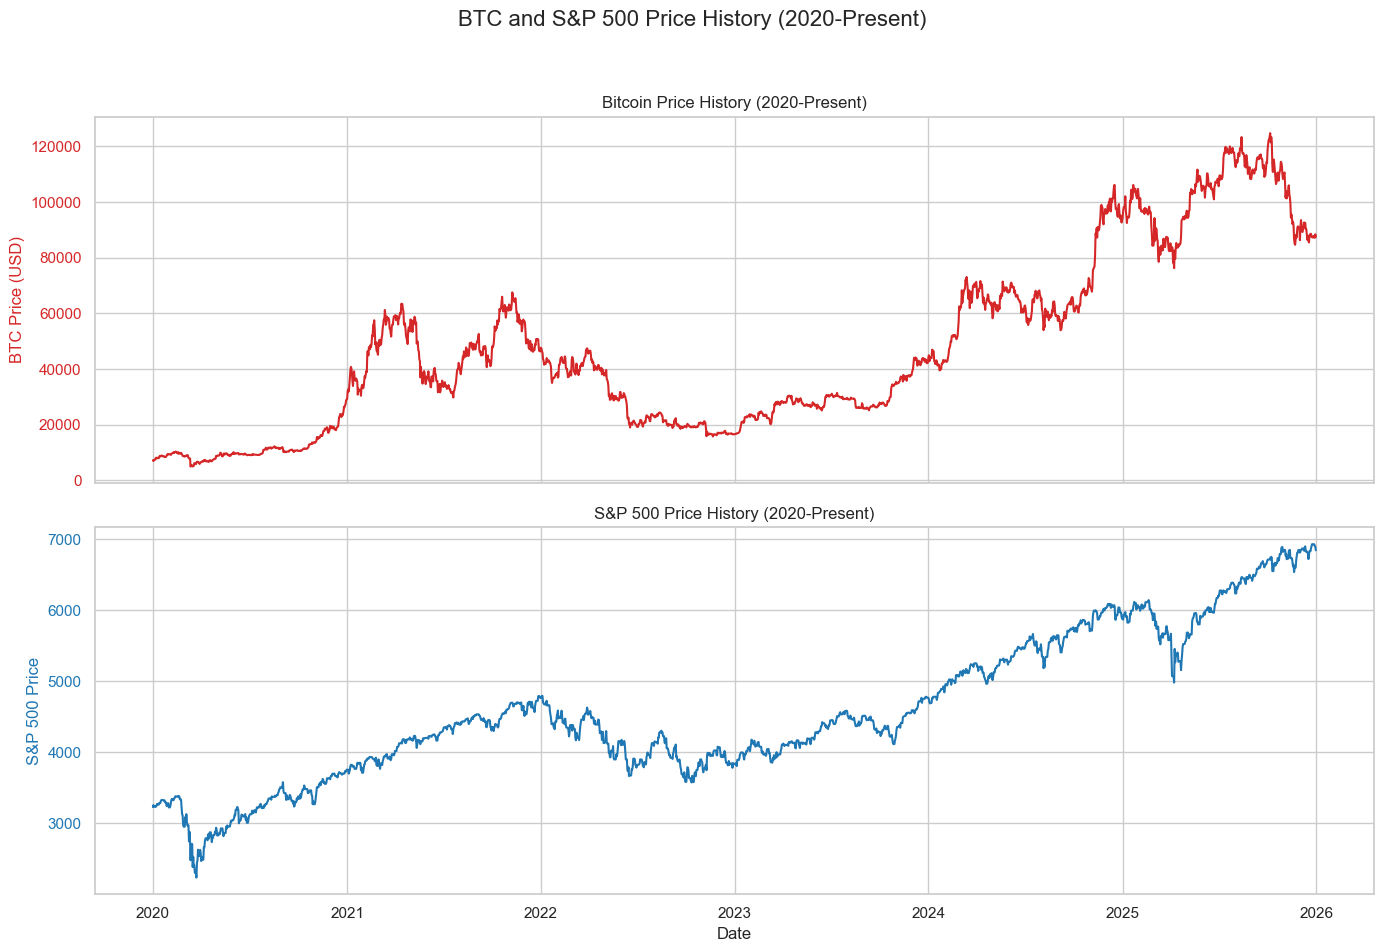

In [106]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot Bitcoin
color = 'tab:red'
ax1.set_ylabel('BTC Price (USD)', color=color)
ax1.plot(data_recent.index, data_recent['BTC-USD'], color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Bitcoin Price History (2020-Present)')
ax1.grid(True)

# Plot S&P 500
color = 'tab:blue'
ax2.set_ylabel('S&P 500 Price', color=color)
ax2.plot(data_recent.index, data_recent['^GSPC'], color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_title('S&P 500 Price History (2020-Present)')
ax2.grid(True)

ax2.set_xlabel('Date')
fig.suptitle('BTC and S&P 500 Price History (2020-Present)', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 3.2. Correlation Analysis (2020-Present)

Correlation Matrix (2020-Present):
          BTC-USD     ^GSPC
BTC-USD  1.000000  0.352236
^GSPC    0.352236  1.000000


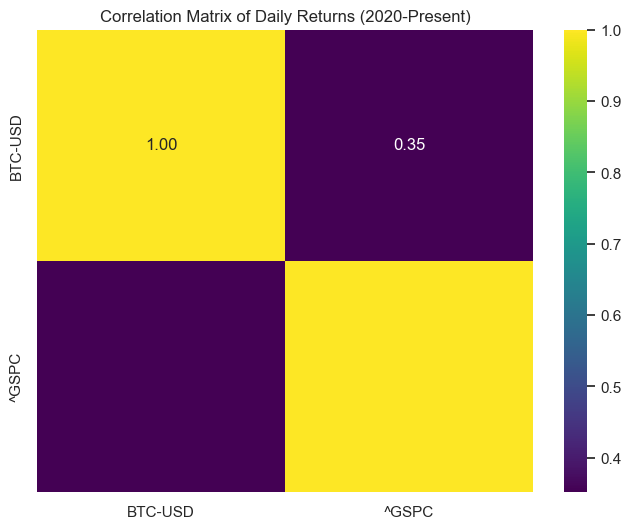

In [107]:
correlation_matrix_recent = returns_recent.corr()
print("Correlation Matrix (2020-Present):")
print(correlation_matrix_recent)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_recent, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Matrix of Daily Returns (2020-Present)')
plt.show()

### Interpretation

The correlation matrix for the period from 2020 to the present reveals a correlation score of 0.35. This is a notable increase from the 0.21 correlation observed over the full date range, indicating that Bitcoin and the S&P 500 have moved together more closely in recent years. This strengthening relationship suggests that Bitcoin may be becoming more integrated into mainstream financial markets, potentially influenced by factors such as growing institutional investment.